# Week 7 – Neural networks: my experiments
COS30018 Lab 7. The provided `neural_net.ipynb` builds a 784 → 32 → 64 → 10 network in TensorFlow/Keras and gets ~94% on MNIST. The notebook says *"you have to try numerous combinations and pick the best one"*, so that's what I did here:

* **A.** the fundamentals from the lab sheet in plain numpy – activation functions, and one neuron doing forward pass → loss → backprop → gradient descent
* **B.** hyperparameter experiments on MNIST (neurons, activation, optimiser, learning rate, batch size, epochs)
* **C.** a closer look at the best model – confusion matrix + the digits it gets wrong
* **D.** the same kind of network in **PyTorch** → separate notebook `nn_pytorch.ipynb`

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"     # hide TensorFlow's C++ startup messages
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

os.makedirs("figures", exist_ok=True)
plt.rcParams["figure.dpi"] = 110
print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU") or "none (CPU is fine for MNIST)")

TensorFlow 2.21.0 | GPU: none (CPU is fine for MNIST)


## A. Fundamentals in numpy
### Activation functions from the lab sheet

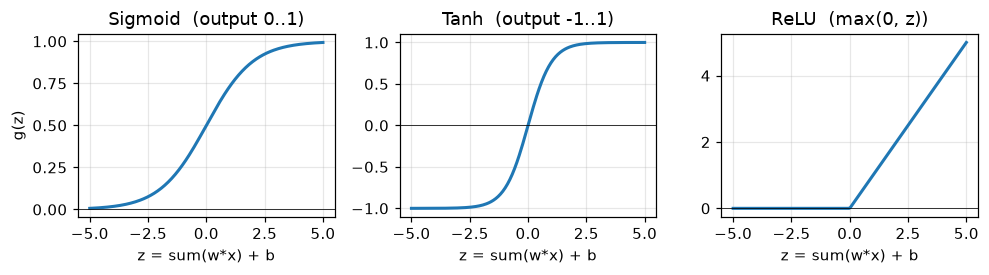

softmax of [2.  1.  0.1] -> [0.659 0.242 0.099] (sums to 1.0 )


In [2]:
z = np.linspace(-5, 5, 200)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

fig, axes = plt.subplots(1, 3, figsize=(9, 2.6), sharex=True)
for ax, y, name, note in [(axes[0], sigmoid, "Sigmoid", "output 0..1"),
                          (axes[1], tanh, "Tanh", "output -1..1"),
                          (axes[2], relu, "ReLU", "max(0, z)")]:
    ax.plot(z, y, lw=2); ax.set_title(f"{name}  ({note})"); ax.grid(alpha=0.3); ax.axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("g(z)")
for ax in axes: ax.set_xlabel("z = sum(w*x) + b")
plt.tight_layout(); plt.savefig("figures/7_1_activation_functions.png", dpi=150); plt.show()

logits = np.array([2.0, 1.0, 0.1])
softmax = np.exp(logits) / np.exp(logits).sum()
print("softmax of", logits, "->", softmax.round(3), "(sums to", softmax.sum(), ")")

Sigmoid and tanh go flat at both ends, so their gradient → 0 there (that's the vanishing gradient problem the sheet mentions). ReLU's gradient is 1 for all positive z, which is why it's the default for hidden layers. Softmax turns the output layer into probabilities that add up to 1.

### One neuron, trained by hand
A single neuron with a sigmoid learning the **AND** gate: forward pass $z = w \cdot x + b$, $a = \sigma(z)$ → binary cross-entropy loss → gradients (backprop) → gradient descent update $w = w - \alpha \frac{\partial J}{\partial w}$.

In [3]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([0, 0, 0, 1], dtype=float)          # AND

rng = np.random.default_rng(0)
w = rng.normal(size=2)                            # weights start random, like the sheet says
b = 0.0
alpha = 1.0
losses = []
for epoch in range(2000):
    zz = X @ w + b                                # forward pass
    a = 1 / (1 + np.exp(-zz))
    loss = -np.mean(y * np.log(a) + (1 - y) * np.log(1 - a))   # binary cross-entropy
    losses.append(loss)
    dz = (a - y) / len(y)                         # backprop: dJ/dz for sigmoid + BCE
    dw, db = X.T @ dz, dz.sum()
    w -= alpha * dw                               # gradient descent
    b -= alpha * db

print("learned weights:", w.round(2), "bias:", round(b, 2))
print("outputs:", (1 / (1 + np.exp(-(X @ w + b)))).round(3), "-> predictions", (X @ w + b > 0).astype(int))
print(f"loss: start {losses[0]:.3f} -> end {losses[-1]:.4f}")

learned weights: [8.82 8.82] bias: -13.4
outputs: [0.    0.01  0.01  0.986] -> predictions [0 0 0 1]
loss: start 0.694 -> end 0.0087


It learns AND (only [1,1] → 1) and the loss drops from ~0.69 to ~0.01. Keras does exactly this, just with thousands of weights and automatic differentiation.

## B. Hyperparameter experiments on MNIST
Same preprocessing as `neural_net.ipynb` (scale to 0–1, flatten to 784). To be fair I hold out **10% of the training set as validation** (that's what you should pick hyperparameters on) and only look at the test set at the end. Every run uses the same seed.

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(len(x_train), 28 * 28) / 255
x_test = x_test.reshape(len(x_test), 28 * 28) / 255

def build(hidden=(32, 64), activation="relu"):
    layers = [tf.keras.layers.InputLayer(shape=(28 * 28,))]
    layers += [tf.keras.layers.Dense(u, activation=activation) for u in hidden]
    layers += [tf.keras.layers.Dense(10, activation="softmax")]
    return tf.keras.models.Sequential(layers)

def run(name, hidden=(32, 64), activation="relu", optimizer="SGD", lr=None, batch_size=32, epochs=5):
    tf.keras.utils.set_random_seed(42)
    model = build(hidden, activation)
    opt_cls = {"SGD": tf.keras.optimizers.SGD, "Adam": tf.keras.optimizers.Adam}[optimizer]
    opt = opt_cls(learning_rate=lr) if lr else opt_cls()
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    hist = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    row = {"experiment": name, "hidden": "-".join(map(str, hidden)), "activation": activation,
           "optimizer": optimizer, "lr": opt.learning_rate.numpy().round(4), "batch": batch_size, "epochs": epochs,
           "params": model.count_params(), "val acc": round(hist.history["val_accuracy"][-1], 4),
           "test acc": round(test_acc, 4), "time (s)": round(time.time() - t0, 1)}
    print(f"{name:<32} val {row['val acc']:.4f} | test {row['test acc']:.4f} | {row['time (s)']}s")
    return row, hist, model

experiments = [
    dict(name="1. lab baseline (SGD)"),
    dict(name="2. more neurons 128-64", hidden=(128, 64)),
    dict(name="3. sigmoid instead of relu", activation="sigmoid"),
    dict(name="4. SGD with lr = 0.1", lr=0.1),
    dict(name="5. batch size 256", batch_size=256),
    dict(name="6. Adam optimiser", optimizer="Adam"),
    dict(name="7. Adam + 128-64 + 10 epochs", optimizer="Adam", hidden=(128, 64), epochs=10),
    dict(name="8. Adam + 256-128 + 10 epochs", optimizer="Adam", hidden=(256, 128), epochs=10),
]
rows, histories, models = [], {}, {}
for e in experiments:
    row, hist, model = run(**e)
    rows.append(row); histories[e["name"]] = hist; models[e["name"]] = model
results = pd.DataFrame(rows).set_index("experiment")
results

1. lab baseline (SGD)            val 0.9523 | test 0.9382 | 17.9s
2. more neurons 128-64           val 0.9587 | test 0.9476 | 19.5s
3. sigmoid instead of relu       val 0.7937 | test 0.7658 | 16.6s
4. SGD with lr = 0.1             val 0.9737 | test 0.9653 | 16.2s
5. batch size 256                val 0.8997 | test 0.8775 | 5.0s
6. Adam optimiser                val 0.9685 | test 0.9677 | 18.5s
7. Adam + 128-64 + 10 epochs     val 0.9768 | test 0.9724 | 48.3s
8. Adam + 256-128 + 10 epochs    val 0.9748 | test 0.9725 | 59.8s


,hidden,activation,optimizer,lr,batch,epochs,params,val acc,test acc,time (s)
experiment,,,,,,,,,,
1. lab baseline (SGD),32-64,relu,SGD,0.010,32,5,27882,0.9523,0.9382,17.9
2. more neurons 128-64,128-64,relu,SGD,0.010,32,5,109386,0.9587,0.9476,19.5
3. sigmoid instead of relu,32-64,sigmoid,SGD,0.010,32,5,27882,0.7937,0.7658,16.6
4. SGD with lr = 0.1,32-64,relu,SGD,0.100,32,5,27882,0.9737,0.9653,16.2
5. batch size 256,32-64,relu,SGD,0.010,256,5,27882,0.8997,0.8775,5.0
6. Adam optimiser,32-64,relu,Adam,0.001,32,5,27882,0.9685,0.9677,18.5
7. Adam + 128-64 + 10 epochs,128-64,relu,Adam,0.001,32,10,109386,0.9768,0.9724,48.3
8. Adam + 256-128 + 10 epochs,256-128,relu,Adam,0.001,32,10,235146,0.9748,0.9725,59.8


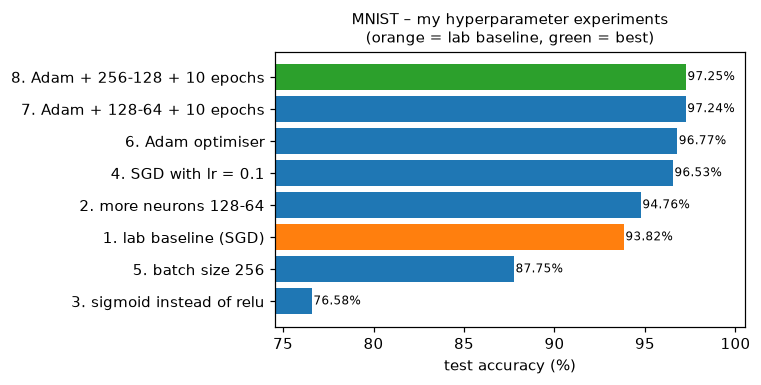

In [5]:
res = results.sort_values("test acc")
fig, ax = plt.subplots(figsize=(7, 3.6))
colors = ["tab:green" if n == res["test acc"].idxmax() else ("tab:orange" if n.startswith("1.") else "tab:blue") for n in res.index]
ax.barh(res.index, res["test acc"] * 100, color=colors)
for i, v in enumerate(res["test acc"] * 100):
    ax.text(v + 0.1, i, f"{v:.2f}%", va="center", fontsize=8)
ax.set_xlim(res["test acc"].min() * 100 - 2, 100.5)
ax.set_xlabel("test accuracy (%)"); ax.set_title("MNIST – my hyperparameter experiments\n(orange = lab baseline, green = best)", fontsize=10)
plt.tight_layout(); plt.savefig("figures/7_2_hyperparameter_results.png", dpi=150); plt.show()

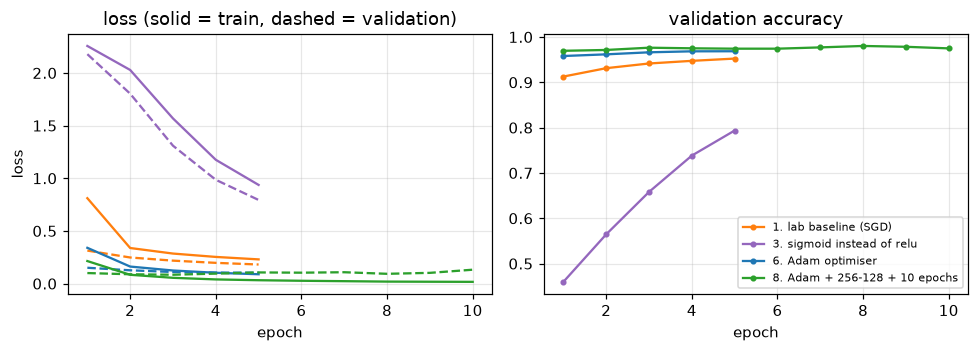

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
for name, color in [("1. lab baseline (SGD)", "tab:orange"), ("3. sigmoid instead of relu", "tab:purple"),
                    ("6. Adam optimiser", "tab:blue"), ("8. Adam + 256-128 + 10 epochs", "tab:green")]:
    h = histories[name].history
    ep = range(1, len(h["loss"]) + 1)
    axes[0].plot(ep, h["loss"], "-", color=color, label=name)
    axes[0].plot(ep, h["val_loss"], "--", color=color)
    axes[1].plot(ep, h["val_accuracy"], "-o", ms=3, color=color, label=name)
axes[0].set_title("loss (solid = train, dashed = validation)"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[1].set_title("validation accuracy"); axes[1].set_xlabel("epoch")
axes[1].legend(fontsize=7, loc="lower right")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("figures/7_3_learning_curves.png", dpi=150); plt.show()

What I take from the table:
* **Optimiser matters most** – Adam beats plain SGD (default lr 0.01) by a few % with the exact same network.
* Plain SGD just needs a bigger learning rate (0.1 gets most of the way to Adam).
* **Sigmoid** learns much slower than ReLU in 5 epochs (flat gradients).
* **Bigger batch (256)** = 8× fewer weight updates per epoch → worse after 5 epochs (it'd need more epochs).
* More neurons + more epochs help a bit more, but the gain gets small – and the bigger nets start to overfit (validation loss creeps back up while training loss keeps falling).

## C. A closer look at the best model

best: 8. Adam + 256-128 + 10 epochs | test accuracy: 0.9725


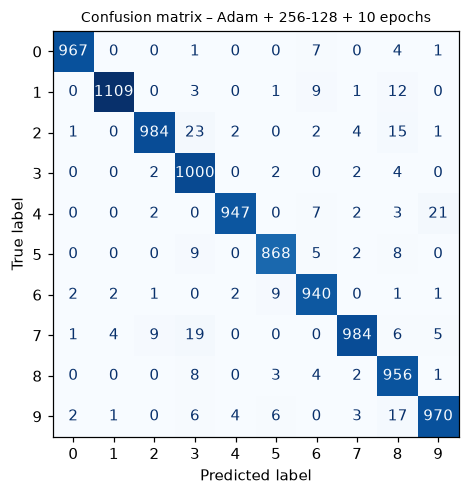

most common mistake: true 2 predicted as 3 (23 times)
top 4 mix-ups: 2->3 (23), 4->9 (21), 7->3 (19), 9->8 (17)


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

best_name = results["test acc"].idxmax()
best = models[best_name]
pred = best.predict(x_test, verbose=0).argmax(axis=1)
print("best:", best_name, "| test accuracy:", (pred == y_test).mean())

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred)).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"Confusion matrix – {best_name[3:]}", fontsize=9)
plt.tight_layout(); plt.savefig("figures/7_4_confusion_matrix.png", dpi=150); plt.show()

cm = confusion_matrix(y_test, pred)
np.fill_diagonal(cm, 0)
i, j = np.unravel_index(cm.argmax(), cm.shape)
print(f"most common mistake: true {i} predicted as {j} ({cm[i, j]} times)")
top = sorted(((cm[a, b], a, b) for a in range(10) for b in range(10)), reverse=True)[:4]
print("top 4 mix-ups:", ", ".join(f"{a}->{b} ({n})" for n, a, b in top))

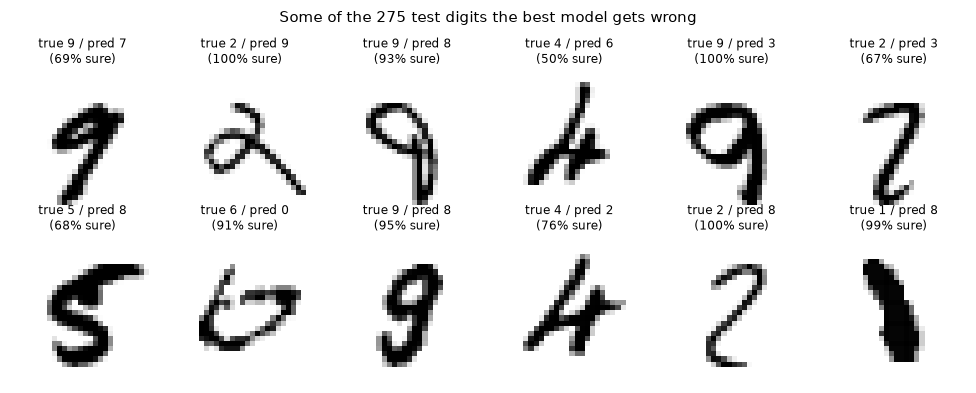

In [8]:
wrong = np.where(pred != y_test)[0]
probs = best.predict(x_test[wrong], verbose=0)
fig, axes = plt.subplots(2, 6, figsize=(9, 3.6))
for ax, k, p in zip(axes.ravel(), wrong[:12], probs[:12]):
    ax.imshow(x_test[k].reshape(28, 28), cmap="gray_r")
    ax.set_title(f"true {y_test[k]} / pred {p.argmax()}\n({p.max():.0%} sure)", fontsize=8)
    ax.axis("off")
plt.suptitle(f"Some of the {len(wrong)} test digits the best model gets wrong", fontsize=10)
plt.tight_layout(); plt.savefig("figures/7_5_misclassified.png", dpi=150); plt.show()

Most of these are genuinely messy digits (open-topped 4s and 9s, loopy 2s), but some it gets wrong while being ~100% sure, which is a bit worrying. The mix-ups printed above are the 'look-alike' pairs you'd expect (2/3, 4/9, 7/3, 9/8 in my run). An MLP flattens the image, so it doesn't know which pixels are next to each other – that's what CNNs fix.

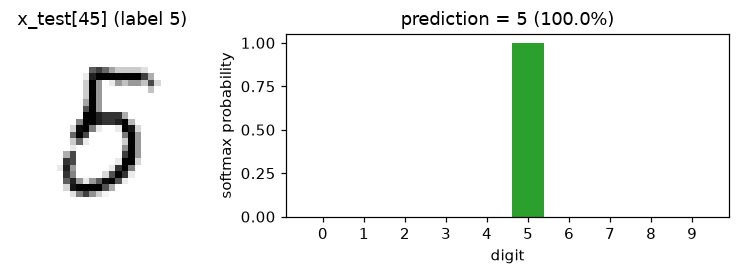

In [9]:
# the same digit the provided notebook looks at (x_test[45])
p45 = best.predict(x_test[45:46], verbose=0)[0]
fig, axes = plt.subplots(1, 2, figsize=(7, 2.6), gridspec_kw={"width_ratios": [1, 2]})
axes[0].imshow(x_test[45].reshape(28, 28), cmap="gray_r"); axes[0].axis("off"); axes[0].set_title(f"x_test[45] (label {y_test[45]})")
axes[1].bar(range(10), p45, color=["tab:green" if d == p45.argmax() else "tab:grey" for d in range(10)])
axes[1].set_xticks(range(10)); axes[1].set_xlabel("digit"); axes[1].set_ylabel("softmax probability")
axes[1].set_title(f"prediction = {p45.argmax()} ({p45.max():.1%})")
plt.tight_layout(); plt.savefig("figures/7_6_prediction_45.png", dpi=150); plt.show()

## Takeaways
* Hidden layer + non-linear activation is what lets the network learn anything beyond a straight line.
* Training = forward pass → loss → backprop → gradient descent, repeated over mini-batches and epochs.
* Optimiser/learning rate made the biggest difference in my experiments, then size + epochs.
* Always check validation curves – the bigger models start overfitting after a few epochs.

*(The PyTorch version is in `nn_pytorch.ipynb` – I had to move it to its own notebook because running TensorFlow and PyTorch training in the same kernel crashed it.)*